In [1]:
print("Hello")

Hello


In [12]:
import sys
print(sys.executable)


c:\Users\Admin\AppData\Local\Programs\Python\Python312\python.exe


In [9]:
!c:\Users\Admin\AppData\Local\Programs\Python\Python38\python.exe -m pip install segmentation-models-pytorch

In [13]:


import os
import time
from glob import glob
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import albumentations as A
from scipy.ndimage.morphology import binary_dilation
import segmentation_models_pytorch as smp
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.23). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\4096189418.py:12: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_dilation


In [14]:
import torch
print(torch.cuda.is_available())  # Should return True if a GPU is available
print(torch.cuda.device_count())  # Number of GPUs detected
print(torch.cuda.get_device_name(0))  # Name of the first GPU (if available)


True
1
NVIDIA GeForce RTX 4060 Ti


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
files_dir = r"D:\Unet\Brain MRI Segmentation\lgg-mri-segmentation\kaggle_3m"
file_paths = glob(f'{files_dir}/*/*[0-9].tif')

In [17]:
csv_path = r"D:\Unet\Brain MRI Segmentation\lgg-mri-segmentation\kaggle_3m\data.csv"
df = pd.read_csv(csv_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient                    110 non-null    object 
 1   RNASeqCluster              92 non-null     float64
 2   MethylationCluster         109 non-null    float64
 3   miRNACluster               110 non-null    int64  
 4   CNCluster                  108 non-null    float64
 5   RPPACluster                98 non-null     float64
 6   OncosignCluster            105 non-null    float64
 7   COCCluster                 110 non-null    int64  
 8   histological_type          109 non-null    float64
 9   neoplasm_histologic_grade  109 non-null    float64
 10  tumor_tissue_site          109 non-null    float64
 11  laterality                 109 non-null    float64
 12  tumor_location             109 non-null    float64
 13  gender                     109 non-null    float64

In [18]:
imputer = SimpleImputer(strategy="most_frequent")

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,2.0,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,2.0,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,2.0,0.0
3,TCGA_CS_4944,2.0,5.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,3.0,6.0,2.0,50.0,3.0,2.0,0.0
4,TCGA_CS_5393,4.0,5.0,2,1.0,2.0,3.0,1,1.0,2.0,1.0,1.0,6.0,2.0,39.0,3.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,TCGA_HT_8563,2.0,5.0,3,1.0,2.0,2.0,2,1.0,2.0,1.0,3.0,2.0,1.0,30.0,3.0,2.0,0.0
106,TCGA_HT_A5RC,2.0,4.0,2,2.0,2.0,3.0,2,1.0,2.0,1.0,1.0,2.0,1.0,70.0,3.0,2.0,1.0
107,TCGA_HT_A616,2.0,5.0,2,1.0,2.0,2.0,1,1.0,1.0,1.0,1.0,2.0,1.0,36.0,3.0,2.0,0.0
108,TCGA_HT_A61A,2.0,5.0,2,1.0,2.0,2.0,1,3.0,1.0,1.0,1.0,6.0,1.0,20.0,3.0,2.0,0.0


In [19]:
print(df.shape)  # Displays the number of rows and columns
print(df.head())  # Displays the first few rows


(110, 18)
        Patient RNASeqCluster MethylationCluster miRNACluster CNCluster  \
0  TCGA_CS_4941           2.0                4.0            2       2.0   
1  TCGA_CS_4942           1.0                5.0            2       1.0   
2  TCGA_CS_4943           1.0                5.0            2       1.0   
3  TCGA_CS_4944           2.0                5.0            2       1.0   
4  TCGA_CS_5393           4.0                5.0            2       1.0   

  RPPACluster OncosignCluster COCCluster histological_type  \
0         2.0             3.0          2               1.0   
1         1.0             2.0          1               1.0   
2         2.0             2.0          1               1.0   
3         2.0             1.0          1               1.0   
4         2.0             3.0          1               1.0   

  neoplasm_histologic_grade tumor_tissue_site laterality tumor_location  \
0                       2.0               1.0        3.0            2.0   
1               

In [20]:
def get_file_row(path):
    """Produces ID of a patient, image and mask filenames from a particular path"""
    path_no_ext, ext = os.path.splitext(path)
    filename = os.path.basename(path)
    
    patient_id = '_'.join(filename.split('_')[:3]) # Patient ID in the csv file consists of 3 first filename segments
    
    return [patient_id, path, f'{path_no_ext}_mask{ext}']

In [21]:
# Show sample
get_file_row(r'D:\Unet\Brain MRI Segmentation\lgg-mri-segmentation\kaggle_3m\TCGA_DU_7010_19860307\TCGA_DU_7010_19860307_45.tif')

['TCGA_DU_7010',
 'D:\\Unet\\Brain MRI Segmentation\\lgg-mri-segmentation\\kaggle_3m\\TCGA_DU_7010_19860307\\TCGA_DU_7010_19860307_45.tif',
 'D:\\Unet\\Brain MRI Segmentation\\lgg-mri-segmentation\\kaggle_3m\\TCGA_DU_7010_19860307\\TCGA_DU_7010_19860307_45_mask.tif']

In [22]:
filenames_df = pd.DataFrame((get_file_row(filename) for filename in file_paths), columns=['Patient', 'image_filename', 'mask_filename'])
filenames_df

,Patient,image_filename,mask_filename
0,TCGA_CS_4941,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
1,TCGA_CS_4941,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
2,TCGA_CS_4941,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
3,TCGA_CS_4941,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
4,TCGA_CS_4941,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
...,...,...,...
3924,TCGA_HT_A61B,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
3925,TCGA_HT_A61B,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
3926,TCGA_HT_A61B,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...
3927,TCGA_HT_A61B,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...,D:\Unet\Brain MRI Segmentation\lgg-mri-segment...


In [23]:
class MriDataset(Dataset):
    def __init__(self, df, transform=None, mean=0.5, std=0.25):
        super(MriDataset, self).__init__()
        self.df = df
        self.transform = transform
        self.mean = mean
        self.std = std
        
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx, raw=False):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_filename'], cv2.IMREAD_UNCHANGED)
        mask = cv2.imread(row['mask_filename'], cv2.IMREAD_GRAYSCALE)
        if raw:
            return img, mask
        
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        
        img = T.functional.to_tensor(img)
        mask = mask // 255
        mask = torch.Tensor(mask)
        return img, mask

In [24]:
df = pd.merge(df, filenames_df, on="Patient")

In [25]:
train_df, test_df = train_test_split(df, test_size=0.3)
test_df, valid_df = train_test_split(test_df, test_size=0.5)

In [26]:
transform = A.Compose([
    A.ChannelDropout(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.ColorJitter(p=0.3),
])

train_dataset = MriDataset(train_df, transform)
valid_dataset = MriDataset(valid_df)
test_dataset = MriDataset(test_df)

In [27]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)

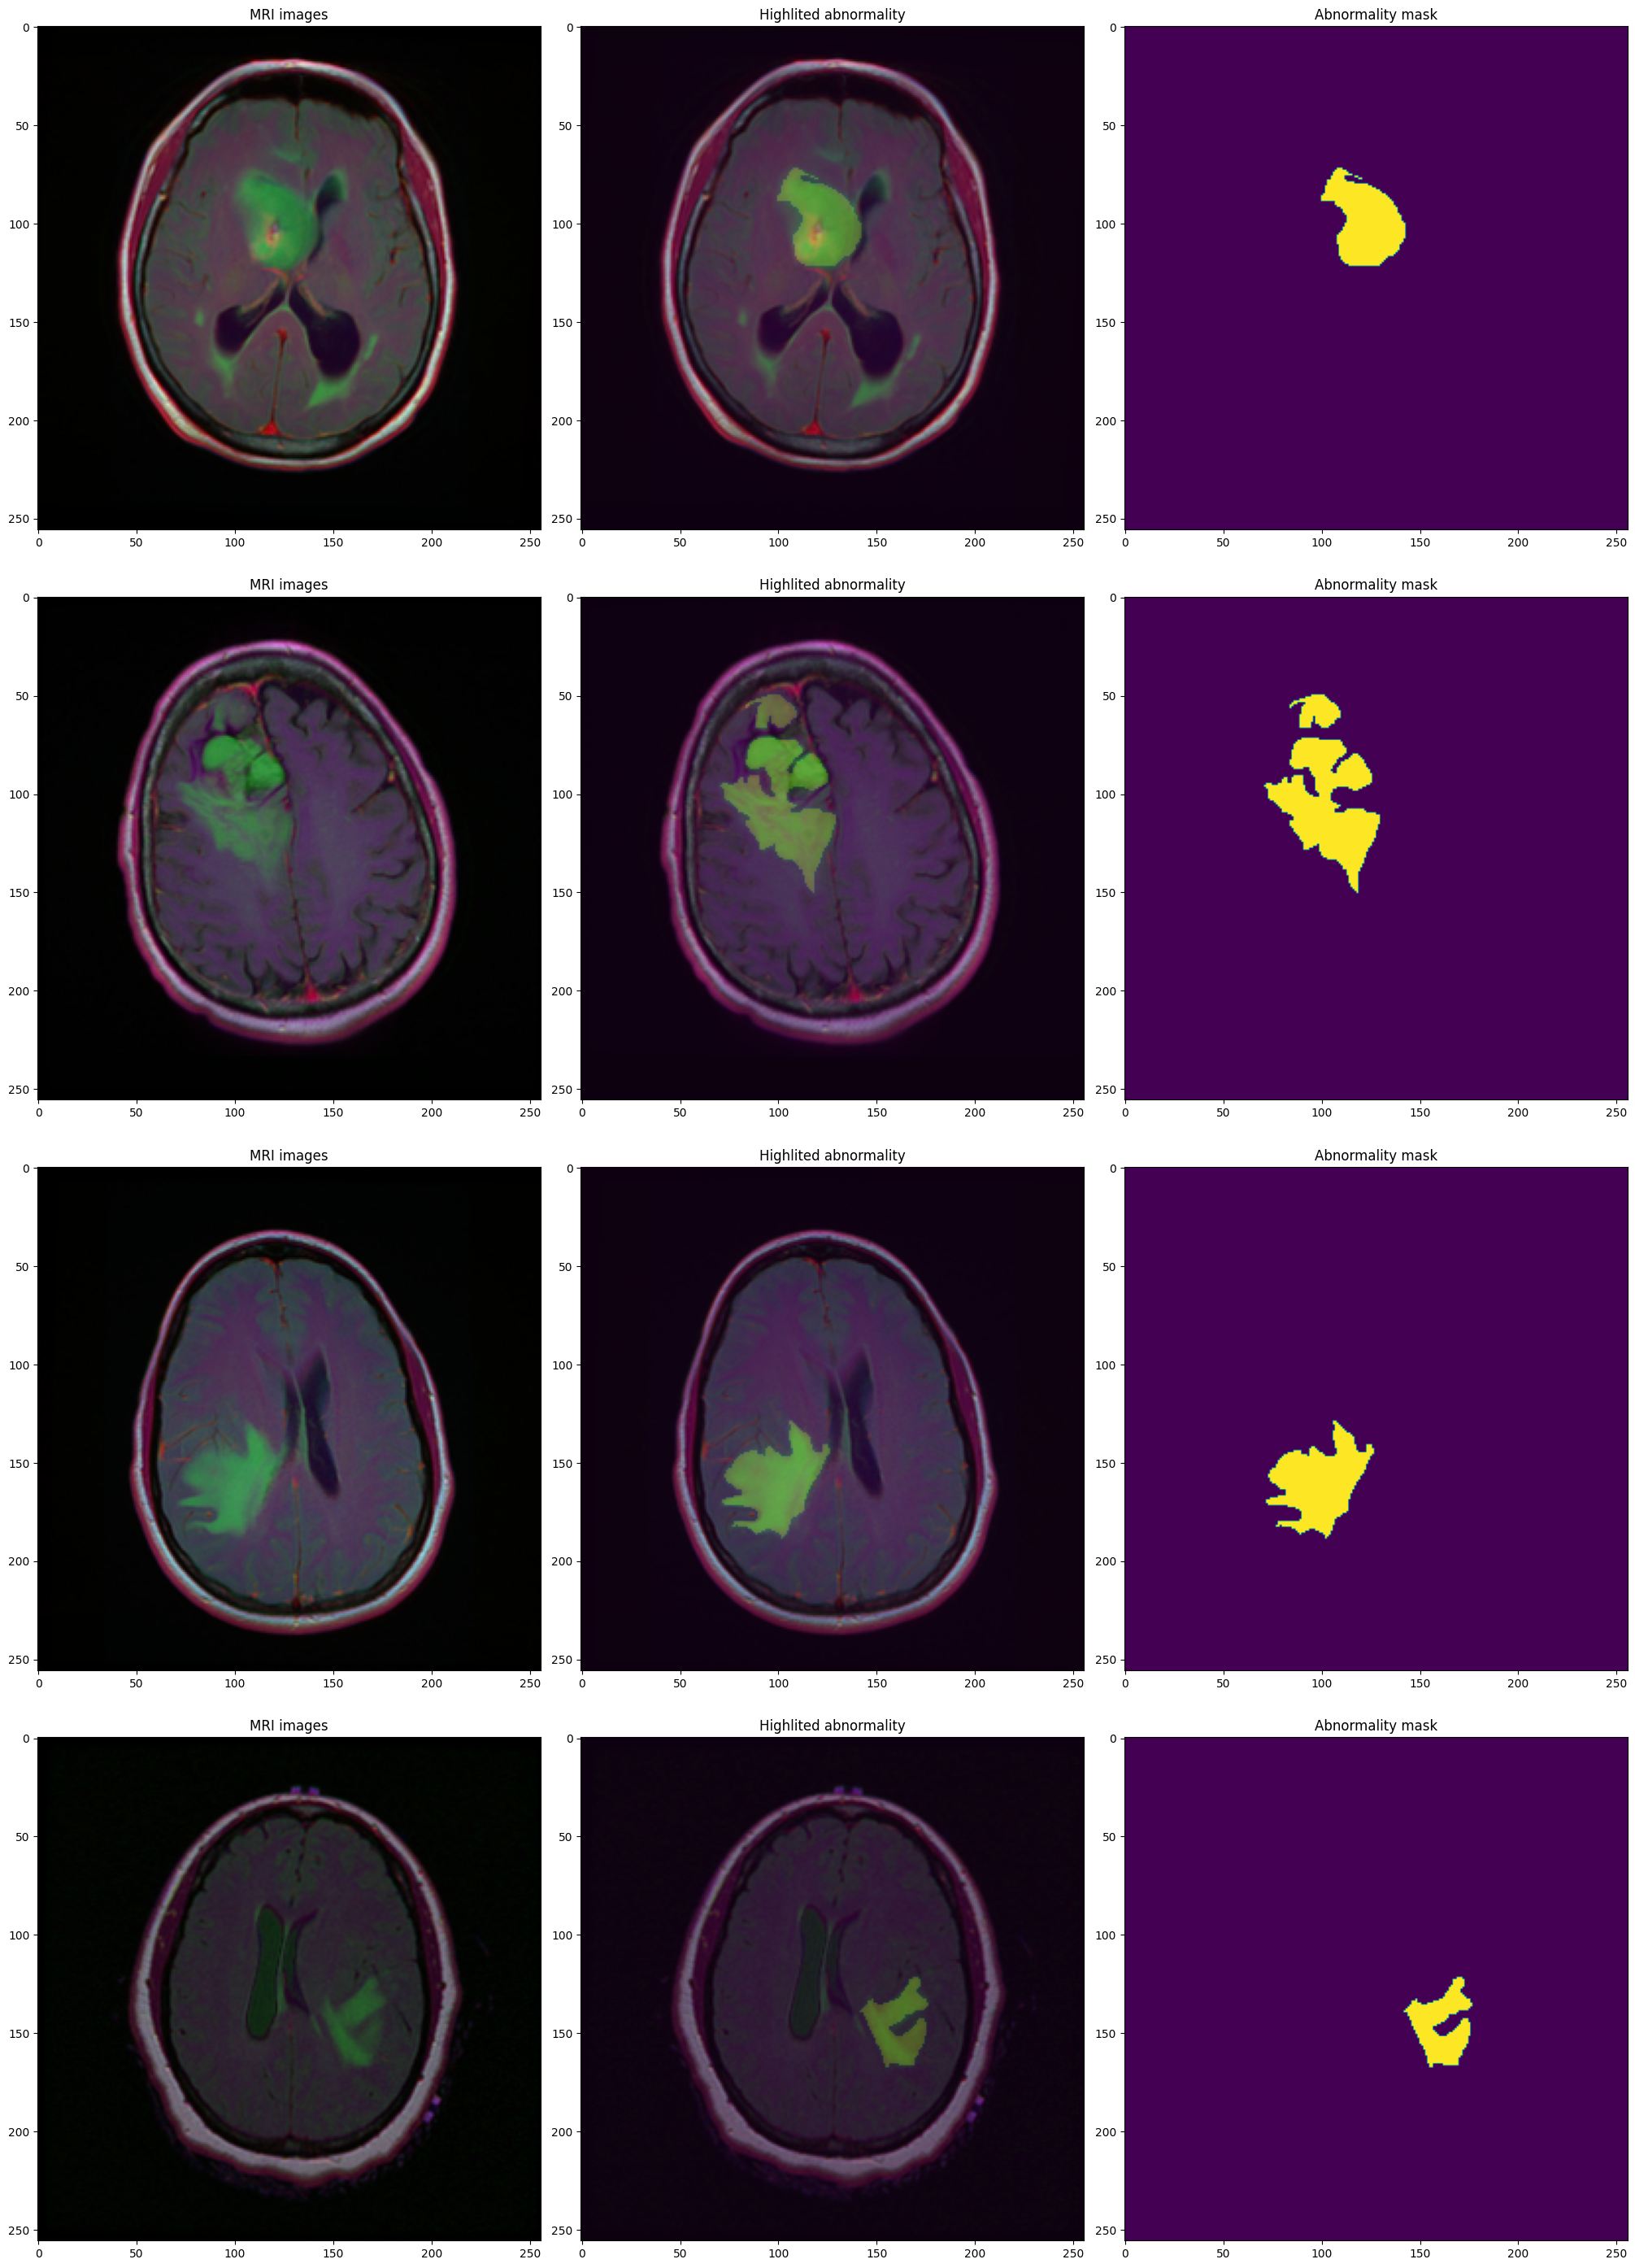

In [30]:
%matplotlib inline
n_examples = 4

fig, axs = plt.subplots(n_examples, 3, figsize=(20, n_examples*7), constrained_layout=True)
i = 0
for ax in axs:
    while True:
        image, mask = train_dataset.__getitem__(i, raw=True)
        i += 1
        if np.any(mask): 
            ax[0].set_title("MRI images")
            ax[0].imshow(image)
            ax[1].set_title("Highlited abnormality")
            ax[1].imshow(image)
            ax[1].imshow(mask, alpha=0.2)
            ax[2].imshow(mask)
            ax[2].set_title("Abnormality mask")
            break
        
    
    

In [28]:
class EarlyStopping():
    """
    Stops training when loss stops decreasing in a PyTorch module.
    """
    def __init__(self, patience:int = 6, min_delta: float = 0, weights_path: str = 'weights.pt'):
        """
        :param patience: number of epochs of non-decreasing loss before stopping
        :param min_delta: minimum difference between best and new loss that is considered
            an improvement
        :paran weights_path: Path to the file that should store the model's weights
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.weights_path = weights_path

    def __call__(self, val_loss: float, model: torch.nn.Module):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.weights_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_weights(self, model: torch.nn.Module):
        """
        Loads weights of the best model.
        :param model: model to which the weigths should be loaded
        """
        return model.load_state_dict(torch.load(self.weights_path))

In [29]:
def iou_pytorch(predictions: torch.Tensor, labels: torch.Tensor, e: float = 1e-7):
    """Calculates Intersection over Union for a tensor of predictions"""
    predictions = torch.where(predictions > 0.5, 1, 0)
    labels = labels.byte()
    
    intersection = (predictions & labels).float().sum((1, 2))
    union = (predictions | labels).float().sum((1, 2))
    
    iou = (intersection + e) / (union + e)
    return iou

def dice_pytorch(predictions: torch.Tensor, labels: torch.Tensor, e: float = 1e-7):
    """Calculates Dice coefficient for a tensor of predictions"""
    predictions = torch.where(predictions > 0.5, 1, 0)
    labels = labels.byte()
    
    intersection = (predictions & labels).float().sum((1, 2))
    return ((2 * intersection) + e) / (predictions.float().sum((1, 2)) + labels.float().sum((1, 2)) + e)

In [30]:
def BCE_dice(output, target, alpha=0.01):
    bce = torch.nn.functional.binary_cross_entropy(output, target)
    soft_dice = 1 - dice_pytorch(output, target).mean()
    return bce + alpha * soft_dice

In [31]:
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)
model.to(device);

In [32]:
def training_loop(epochs, model, train_loader, valid_loader, optimizer, loss_fn, lr_scheduler):
    history = {'train_loss': [], 'val_loss': [], 'val_IoU': [], 'val_dice': []}
    early_stopping = EarlyStopping(patience=7)
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        running_loss = 0
        model.train()
        for i, data in enumerate(tqdm(train_loader)):
            img, mask = data
            img, mask = img.to(device), mask.to(device)
            predictions = model(img)
            predictions = predictions.squeeze(1)
            loss = loss_fn(predictions, mask)
            running_loss += loss.item() * img.size(0)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        model.eval()
        with torch.no_grad():
            running_IoU = 0
            running_dice = 0
            running_valid_loss = 0
            for i, data in enumerate(valid_loader):
                img, mask = data
                img, mask = img.to(device), mask.to(device)
                predictions = model(img)
                predictions = predictions.squeeze(1)
                running_dice += dice_pytorch(predictions, mask).sum().item()
                running_IoU += iou_pytorch(predictions, mask).sum().item()
                loss = loss_fn(predictions, mask)
                running_valid_loss += loss.item() * img.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        val_loss = running_valid_loss / len(valid_loader.dataset)
        val_dice = running_dice / len(valid_loader.dataset)
        val_IoU = running_IoU / len(valid_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_IoU'].append(val_IoU)
        history['val_dice'].append(val_dice)
        print(f'Epoch: {epoch}/{epochs} | Training loss: {train_loss} | Validation loss: {val_loss} | Validation Mean IoU: {val_IoU} '
         f'| Validation Dice coefficient: {val_dice}')
        
        lr_scheduler.step(val_loss)
        if early_stopping(val_loss, model):
            early_stopping.load_weights(model)
            break
    model.eval()
    return history

In [37]:
loss_fn = BCE_dice
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 5
lr_scheduler = ReduceLROnPlateau(optimizer=optimizer, patience=2,factor=0.2)

history = training_loop(epochs, model, train_loader, valid_loader, optimizer, loss_fn, lr_scheduler)

100%|██████████| 172/172 [57:04<00:00, 19.91s/it]


Epoch: 1/5 | Training loss: 0.009586431174793027 | Validation loss: 0.023330357935974152 | Validation Mean IoU: 0.6894540172512248 | Validation Dice coefficient: 0.7238636728060448


100%|██████████| 172/172 [56:47<00:00, 19.81s/it]


Epoch: 2/5 | Training loss: 0.006396901064467701 | Validation loss: 0.007646587011167559 | Validation Mean IoU: 0.8772598525225106 | Validation Dice coefficient: 0.9051397113476769


100%|██████████| 172/172 [56:46<00:00, 19.80s/it]


Epoch: 3/5 | Training loss: 0.006057194654575803 | Validation loss: 0.008362119815359682 | Validation Mean IoU: 0.868327842324467 | Validation Dice coefficient: 0.8942895614494711


100%|██████████| 172/172 [56:46<00:00, 19.80s/it]


Epoch: 4/5 | Training loss: 0.005598631016232751 | Validation loss: 0.005820788508991442 | Validation Mean IoU: 0.901089726464223 | Validation Dice coefficient: 0.9274043762077719


100%|██████████| 172/172 [56:47<00:00, 19.81s/it]


Epoch: 5/5 | Training loss: 0.004303079337897626 | Validation loss: 0.005306069380840508 | Validation Mean IoU: 0.9076680054098872 | Validation Dice coefficient: 0.9324463327052229


### Evaluation

In [ ]:
plt.figure(figsize=(7, 7))
plt.plot(history['train_loss'], label='Training loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.ylim(0, 0.01)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.plot(history['val_IoU'], label='Validation mean Jaccard index')
plt.plot(history['val_dice'], label='Validation Dice coefficient')
plt.legend()
plt.show()

### Test Evaluation

In [ ]:
with torch.no_grad():
    running_IoU = 0
    running_dice = 0
    running_loss = 0
    for i, data in enumerate(test_loader):
        img, mask = data
        img, mask = img.to(device), mask.to(device)
        predictions = model(img)
        predictions = predictions.squeeze(1)
        running_dice += dice_pytorch(predictions, mask).sum().item()
        running_IoU += iou_pytorch(predictions, mask).sum().item()
        loss = loss_fn(predictions, mask)
        running_loss += loss.item() * img.size(0)
    loss = running_loss / len(test_dataset)
    dice = running_dice / len(test_dataset)
    IoU = running_IoU / len(test_dataset)
    
    print(f'Tests: loss: {loss} | Mean IoU: {IoU} | Dice coefficient: {dice}')

In [29]:
%matplotlib inline

width = 3
columns = 10
n_examples = columns * width

fig, axs = plt.subplots(columns, width, figsize=(7*width , 7*columns), constrained_layout=True)
red_patch = mpatches.Patch(color='red', label='The red data')
fig.legend(loc='upper right',handles=[
    mpatches.Patch(color='red', label='Ground truth'),
    mpatches.Patch(color='green', label='Predicted abnormality')])
i = 0
with torch.no_grad():
    for data in test_loader:
        image, mask = data
        mask = mask[0]
        if not mask.byte().any():
            continue
        image = image.to(device)
        prediction = model(image).to('cpu')[0][0]
        prediction = torch.where(prediction > 0.5, 1, 0)
        prediction_edges = prediction - binary_dilation(prediction)
        ground_truth = mask - binary_dilation(mask)
        image[0, 0, ground_truth.bool()] = 1
        image[0, 1, prediction_edges.bool()] = 1
        
        axs[i//width][i%width].imshow(image[0].to('cpu').permute(1, 2, 0))
        if n_examples == i + 1:
            break
        i += 1


C:\Users\Admin\AppData\Local\Temp\ipykernel_10600\3435014965.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  prediction_edges = prediction - binary_dilation(prediction)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10600\3435014965.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ground_truth = mask - binary_dilation(mask)


### Custom Test

GrayScaled test

Main Test 

In [30]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from scipy.ndimage import binary_dilation
import segmentation_models_pytorch as smp

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained model
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)
# Update the path to match your weights file
model.load_state_dict(torch.load(r"D:\Project\weights.pt", map_location=device))
model.to(device)
model.eval()

# Function to preprocess image
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),  # Resize to match the input size expected by the model
    ])
    return transform(image).unsqueeze(0)  # Add batch dimension

# Function to preprocess mask
def preprocess_mask(mask_path):
    mask = Image.open(mask_path).convert("L")  # Convert to grayscale
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),  # Resize to match the model output size
    ])
    return transform(mask)

# Test function
def test_single_image(image_path, mask_path):
    # Preprocess image and mask
    image = preprocess_image(image_path).to(device)
    mask = preprocess_mask(mask_path).to(device)

    # Get prediction
    with torch.no_grad():
        prediction = model(image).squeeze(0).squeeze(0).cpu().numpy()
        prediction = (prediction > 0.5).astype(np.uint8)

    # Check for tumor detection
    mask = mask.squeeze(0).cpu().numpy().astype(np.uint8)  # Convert mask to uint8
    prediction = prediction.astype(np.uint8)  # Convert prediction to uint8
    tumor_detected = np.any(prediction & mask)  # Check overlap of prediction and ground truth

    # Print results
    if tumor_detected:
        print("Tumor detected.")
    else:
        print("No tumor detected.")

    return tumor_detected

# Test example
image_path = r"D:\Project\lgg-mri-segmentation\kaggle_3m\TCGA_CS_6186_20000601\TCGA_CS_6186_20000601_8.tif"
mask_path = r"D:\Project\lgg-mri-segmentation\kaggle_3m\TCGA_CS_6186_20000601\TCGA_CS_6186_20000601_8_mask.tif"
test_single_image(image_path, mask_path)


C:\Users\Admin\AppData\Local\Temp\ipykernel_14648\323874434.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\Project\weights.pt", m

No tumor detected.


np.False_

### Classification Model

In [50]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the ResNet model
class TumorResNet(torch.nn.Module):
    def __init__(self, num_classes):
        super(TumorResNet, self).__init__()
        self.model = models.resnet50(pretrained=False)  # Start from scratch
        num_ftrs = self.model.fc.in_features
        self.model.fc = torch.nn.Linear(num_ftrs, num_classes)  # Modify final layer

    def forward(self, x):
        return self.model(x)

# Initialize the model
num_classes = 4  # Glioma, Meningioma, Pituitary, No Tumor
model = TumorResNet(num_classes)
model.to(device)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Dataset and DataLoader preparation (Example for one folder)
def load_dataset(folder_path, class_label):
    dataset = []
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        if os.path.isfile(image_path):
            image = Image.open(image_path).convert("RGB")
            image = transform(image)
            dataset.append((image, class_label))
    return dataset

def prepare_data(tumor_folders, no_tumor_folder):
    dataset = []
    for folder_path, class_label in tumor_folders.items():
        dataset.extend(load_dataset(folder_path, class_label))
    dataset.extend(load_dataset(no_tumor_folder, class_mapping["no_tumor"]))
    return dataset

# Map class folders to numeric labels
class_mapping = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "no_tumor": 3,
}

# Paths to folders
tumor_folders = {
    r"D:\\IUB_ClassRoom\\CSE471\\Project\\Datasets\\Brain_MRI_Dataset\\Training\\glioma": class_mapping["glioma"],
    r"D:\\IUB_ClassRoom\\CSE471\\Project\\Datasets\\Brain_MRI_Dataset\\Training\\meningioma": class_mapping["meningioma"],
    r"D:\\IUB_ClassRoom\\CSE471\\Project\\Datasets\\Brain_MRI_Dataset\\Training\\pituitary": class_mapping["pituitary"],
}
no_tumor_folder = r"D:\\IUB_ClassRoom\\CSE471\\Project\\Datasets\\Brain_MRI_Dataset\\Training\\notumor"

# Prepare dataset
dataset = prepare_data(tumor_folders, no_tumor_folder)

# Split into training and validation
def split_dataset(dataset, split_ratio=0.8):
    np.random.shuffle(dataset)
    split_idx = int(len(dataset) * split_ratio)
    train_data = dataset[:split_idx]
    val_data = dataset[split_idx:]
    return train_data, val_data

train_data, val_data = split_dataset(dataset)

# DataLoader
def create_dataloader(data, batch_size=16):
    images, labels = zip(*data)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    dataset = torch.utils.data.TensorDataset(images, labels)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_loader = create_dataloader(train_data)
val_loader = create_dataloader(val_data)

# Training loop
def train_model(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# Train the model
train_model(model, train_loader, val_loader, epochs=10)

# Save the model
torch.save(model.state_dict(), r"D:\\Project\\weights_resnet_scratch.pt")


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


: 

With Threading 

In [7]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from concurrent.futures import ThreadPoolExecutor
import time

start_time = time.time()

# Folder paths
tumor_folders = [
    r"D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\glioma",
    r"D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\meningioma",
    r"D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\pituitary"
]
no_tumor_folder = r"D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\notumor"

# Class labels
class_labels = {
    'glioma': 0,
    'meningioma': 1,
    'pituitary': 2,
    'no_tumor': 3
}

# Enable OpenCV optimizations
cv2.setUseOptimized(True)

# Function to preprocess a single image
def preprocess_image(img_path, label, img_size=(128, 128)):
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
        img = img / 255.0  # Normalize
        return img, label
    return None, None

# Function to load and preprocess images using threading
def load_images_from_folders(tumor_folders, no_tumor_folder, class_labels, img_size=(128, 128), max_workers=8):
    images = []
    labels = []

    def process_folder(folder, label):
        folder_images = []
        folder_labels = []
        filenames = os.listdir(folder)
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            results = executor.map(
                lambda filename: preprocess_image(os.path.join(folder, filename), label, img_size),
                filenames
            )
            for img, lbl in results:
                if img is not None:
                    folder_images.append(img)
                    folder_labels.append(lbl)
        return folder_images, folder_labels

    # Load tumor images
    for folder in tumor_folders:
        class_name = os.path.basename(folder)
        label = class_labels[class_name]
        folder_images, folder_labels = process_folder(folder, label)
        images.extend(folder_images)
        labels.extend(folder_labels)

    # Load no tumor images
    no_tumor_images, no_tumor_labels = process_folder(no_tumor_folder, class_labels['no_tumor'])
    images.extend(no_tumor_images)
    labels.extend(no_tumor_labels)

    return np.array(images), np.array(labels)

# Load dataset
X_images, y_labels = load_images_from_folders(tumor_folders, no_tumor_folder, class_labels)

# One-hot encode labels
num_classes = len(class_labels)
y_labels = to_categorical(y_labels, num_classes)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_images, y_labels, test_size=0.2, random_state=42)

# Build a CNN model
threaded_model_multiclass = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Multi-class classification
])

# Compile the model
threaded_model_multiclass.compile(optimizer=Adam(learning_rate=0.001),
                                  loss='categorical_crossentropy',
                                  metrics=['accuracy'])

# Train the model
Threaded_history = threaded_model_multiclass.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Save the model
threaded_model_multiclass.save('threaded_brain_mri_multiclass_model.h5')

end_time = time.time()
threading_elapsed_time = end_time - start_time

# Print total execution time
print(f"Total Execution Time with Threading: {threading_elapsed_time:.2f} seconds")

# Prediction function for new images
def predict_tumor(img_path, model, class_labels):
    class_names = {v: k for k, v in class_labels.items()}  # Reverse mapping
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction, axis=1)
    return class_names[predicted_class[0]]


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.5492 - loss: 1.0495 - val_accuracy: 0.8556 - val_loss: 0.4514
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.8001 - loss: 0.5289 - val_accuracy: 0.8723 - val_loss: 0.3692
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.8642 - loss: 0.3737 - val_accuracy: 0.8801 - val_loss: 0.3201
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.8893 - loss: 0.2926 - val_accuracy: 0.8810 - val_loss: 0.2869
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.9051 - loss: 0.2452 - val_accuracy: 0.9125 - val_loss: 0.2319
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9293 - loss: 0.1859 - val_accuracy: 0.9064 - val_loss: 0.2427
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9432 - loss: 0.1577 - val_accuracy: 0.9221 - val_loss: 0.2045
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9525 - loss: 0

Total Execution Time with Threading: 189.23 seconds


Without Threading

In [8]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelBinarizer
import time 

start_time = time.time()
# Folder paths
tumor_folders = [
    "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\glioma",
    "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\meningioma",
    "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\pituitary"
]
no_tumor_folder = r"D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\notumor"


# Class labels
class_labels = {
    'glioma': 0,
    'meningioma': 1,
    'pituitary': 2,
    'no_tumor': 3
}

# Function to load and preprocess images from folders
def load_images_from_folders(tumor_folders, no_tumor_folder, class_labels, img_size=(128, 128)):
    images = []
    labels = []

    # Load tumor images
    for folder in tumor_folders:
        class_name = os.path.basename(folder)  # Extract class name from folder path
        label = class_labels[class_name]
        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                img = img / 255.0  # Normalize
                images.append(img)
                labels.append(label)

    # Load no tumor images
    for filename in os.listdir(no_tumor_folder):
        img_path = os.path.join(no_tumor_folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, img_size)
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(class_labels['no_tumor'])

    return np.array(images), np.array(labels)

# Load dataset
X_images, y_labels = load_images_from_folders(tumor_folders, no_tumor_folder, class_labels)

# One-hot encode labels
num_classes = len(class_labels)
y_labels = to_categorical(y_labels, num_classes)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_images, y_labels, test_size=0.2, random_state=42)

# Build a CNN model
model_multiclass = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Multi-class classification
])

# Compile the model
model_multiclass.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model
history = model_multiclass.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Save the model
model_multiclass.save('org_brain_mri_multiclass_model.h5')
end_time = time.time()

org_elapsed_time = end_time - start_time

# Print total execution time
print(f"Total Execution Time with Threading: {end_time - start_time:.2f} seconds")

# Prediction function for new images
def predict_tumor(img_path, model, class_labels):
    class_names = {v: k for k, v in class_labels.items()}  # Reverse mapping
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction, axis=1)
    return class_names[predicted_class[0]]





<>:18: SyntaxWarning: invalid escape sequence '\I'
<>:19: SyntaxWarning: invalid escape sequence '\I'
<>:20: SyntaxWarning: invalid escape sequence '\I'
<>:18: SyntaxWarning: invalid escape sequence '\I'
<>:19: SyntaxWarning: invalid escape sequence '\I'
<>:20: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\2647163330.py:18: SyntaxWarning: invalid escape sequence '\I'
  "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\glioma",
C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\2647163330.py:19: SyntaxWarning: invalid escape sequence '\I'
  "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\meningioma",
C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\2647163330.py:20: SyntaxWarning: invalid escape sequence '\I'
  "D:\IUB_ClassRoom\CSE471\Project\Datasets\Brain_MRI_Dataset\Training\pituitary"


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.5349 - loss: 1.0770 - val_accuracy: 0.8276 - val_loss: 0.4688
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.8006 - loss: 0.5124 - val_accuracy: 0.8679 - val_loss: 0.3488
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.8636 - loss: 0.3680 - val_accuracy: 0.8976 - val_loss: 0.2751
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.9023 - loss: 0.2758 - val_accuracy: 0.9169 - val_loss: 0.2394
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.9261 - loss: 0.2133 - val_accuracy: 0.9213 - val_loss: 0.2104
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9443 - loss: 0.1656 - val_accuracy: 0.9248 - val_loss: 0.1932
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9511 - loss: 0.1480 - val_accuracy: 0.9344 - val_loss: 0.1930
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.9577 - loss: 0

Total Execution Time with Threading: 197.37 seconds


Exicution Time Comparison

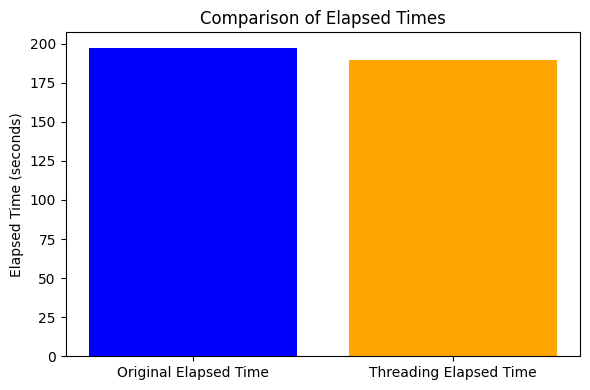

In [9]:
import matplotlib.pyplot as plt

# Labels for the bars
labels = ['Original Elapsed Time', 'Threading Elapsed Time']
values = [org_elapsed_time, threading_elapsed_time]

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['blue', 'orange'])

# Adding labels and title
plt.ylabel('Elapsed Time (seconds)')
plt.title('Comparison of Elapsed Times')

# Show the chart
plt.tight_layout()
plt.show()

Evaluating the two models

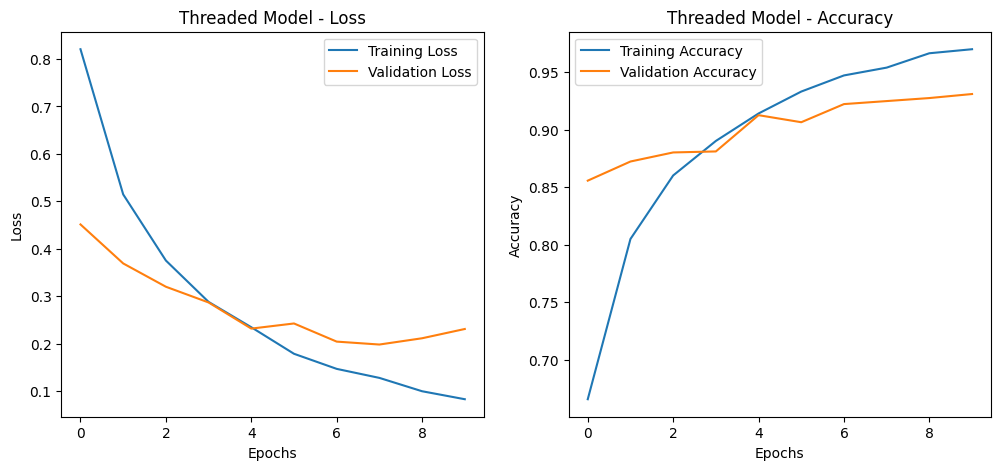

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


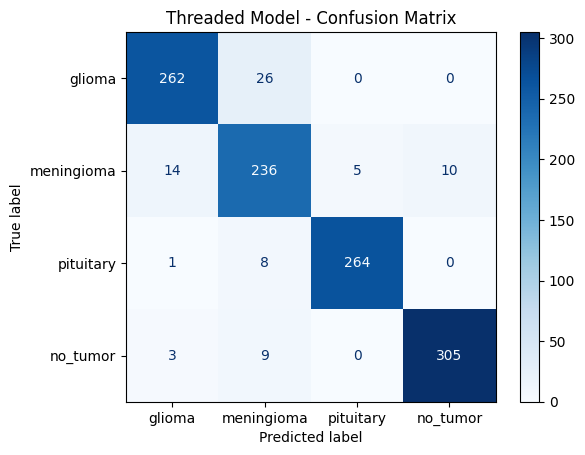

Threaded Model - Classification Report:

              precision    recall  f1-score   support

      glioma       0.94      0.91      0.92       288
  meningioma       0.85      0.89      0.87       265
   pituitary       0.98      0.97      0.97       273
    no_tumor       0.97      0.96      0.97       317

    accuracy                           0.93      1143
   macro avg       0.93      0.93      0.93      1143
weighted avg       0.93      0.93      0.93      1143



36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


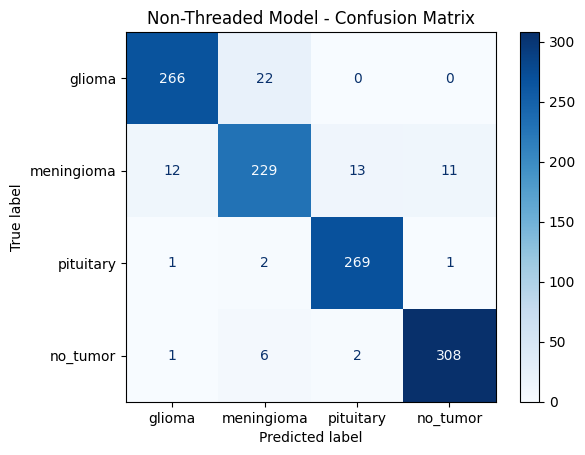

Non-Threaded Model - Classification Report:

              precision    recall  f1-score   support

      glioma       0.95      0.92      0.94       288
  meningioma       0.88      0.86      0.87       265
   pituitary       0.95      0.99      0.97       273
    no_tumor       0.96      0.97      0.97       317

    accuracy                           0.94      1143
   macro avg       0.94      0.94      0.94      1143
weighted avg       0.94      0.94      0.94      1143

Threaded Model Training Time: 189.23 seconds
Non-Threaded Model Training Time: 197.37 seconds


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Function to plot loss and accuracy graphs
def plot_loss_accuracy(history, title):
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

# Function to evaluate model using confusion matrix
def evaluate_model(model, X_test, y_test, class_labels, title):
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    # Confusion matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(class_labels.keys()))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{title} - Confusion Matrix')
    plt.show()
    
    # Classification report
    print(f"{title} - Classification Report:\n")
    print(classification_report(y_true_classes, y_pred_classes, target_names=list(class_labels.keys())))

# Plot and evaluate the threaded model
plot_loss_accuracy(Threaded_history, "Threaded Model")
evaluate_model(threaded_model_multiclass, X_test, y_test, class_labels, "Threaded Model")

# Load and evaluate the non-threaded model
non_threaded_model = load_model('org_brain_mri_multiclass_model.h5')
evaluate_model(non_threaded_model, X_test, y_test, class_labels, "Non-Threaded Model")

# Compare training times
print(f"Threaded Model Training Time: {threading_elapsed_time:.2f} seconds")
print(f"Non-Threaded Model Training Time: {org_elapsed_time:.2f} seconds")


### Testing the Hybrid Model

In [47]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import segmentation_models_pytorch as smp

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained model
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)
# Update the path to match your weights file
model.load_state_dict(torch.load(r"D:\Project\weights.pt", map_location=device))
model.to(device)
model.eval()

# Function to preprocess image
def preprocess_image(image_path):
    image = Image.open(image_path).convert("L")  # Ensure the image is grayscale
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize to match the input size expected by the model
        transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
        transforms.ToTensor(),          # Convert to tensor
    ])
    return transform(image).unsqueeze(0)  # Add batch dimension

# Function to test single image and detect tumor
def detect_tumor(image_path):
    # Preprocess image
    image = preprocess_image(image_path).to(device)

    # Get prediction
    with torch.no_grad():
        prediction = model(image).squeeze(0).squeeze(0).cpu().numpy()
        prediction = (prediction > 0.5).astype(np.uint8)  # Threshold to get binary mask

    # Check if tumor is detected (any non-zero value in the prediction mask)
    tumor_detected = np.any(prediction)

    return tumor_detected

# Test example
# Test example
image_path = r"D:\Data_set\Training\notumor\Tr-no_0057.jpg"
bool_val = detect_tumor(image_path)  # Corrected function name
if bool_val:
    result = predict_tumor(image_path, model_multiclass, class_labels)
    print("Predicted Class:", result)
else:
    print("No tumor detected in the image.")


C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\618059202.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\Project\weights.pt", m

No tumor detected in the image.


Evaluating the Hybrid Model

C:\Users\Admin\AppData\Local\Temp\ipykernel_10648\3981465760.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\Project\weights.pt", 

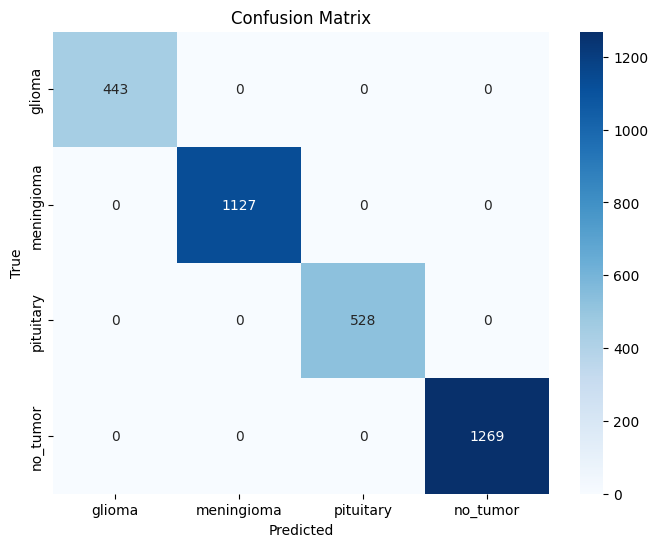

In [49]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import segmentation_models_pytorch as smp
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained model
model = smp.Unet(
    encoder_name="efficientnet-b7",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation='sigmoid',
)
# Update the path to match your weights file
model.load_state_dict(torch.load(r"D:\Project\weights.pt", map_location=device))
model.to(device)
model.eval()

# Mapping class folders to numeric labels
class_mapping = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "no_tumor": 3,
}

# Function to preprocess image
def preprocess_image(image_path):
    image = Image.open(image_path).convert("L")  # Ensure the image is grayscale
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize to match the input size expected by the model
        transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
        transforms.ToTensor(),  # Convert to tensor
    ])
    return transform(image).unsqueeze(0)  # Add batch dimension

# Function to predict tumor class
def predict_tumor(image_path):
    # Preprocess image
    image = preprocess_image(image_path).to(device)

    # Get prediction
    with torch.no_grad():
        prediction = model(image).squeeze(0).squeeze(0).cpu().numpy()
        prediction = (prediction > 0.5).astype(np.uint8)  # Threshold to get binary mask

    # If tumor is detected, assume it belongs to one of the classes based on the folder
    tumor_detected = np.any(prediction)
    return tumor_detected

# Function to get the predicted class from the folder name
def get_class_from_folder(folder_path):
    for class_name, class_id in class_mapping.items():
        if class_name in folder_path.lower():
            return class_id
    return -1  # Return -1 if no class is matched

# Function to evaluate and generate confusion matrix
def generate_confusion_matrix(tumor_folders, no_tumor_folder):
    y_true = []
    y_pred = []

    # Iterate over tumor folders
    for folder_path in tumor_folders:
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            if os.path.isfile(image_path):
                # Get ground truth label from folder
                true_label = get_class_from_folder(folder_path)
                y_true.append(true_label)

                # Predict class
                tumor_detected = predict_tumor(image_path)
                predicted_label = 3 if not tumor_detected else get_class_from_folder(folder_path)  # Assume no tumor if not detected
                y_pred.append(predicted_label)

    # Iterate over no_tumor_folder
    for image_name in os.listdir(no_tumor_folder):
        image_path = os.path.join(no_tumor_folder, image_name)
        if os.path.isfile(image_path):
            # True label is 'no tumor' class
            true_label = class_mapping["no_tumor"]
            y_true.append(true_label)

            # Predict class
            tumor_detected = predict_tumor(image_path)
            predicted_label = class_mapping["no_tumor"] if not tumor_detected else get_class_from_folder(image_path)
            y_pred.append(predicted_label)

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(class_mapping.values()))
    
    # Plot confusion matrix using Seaborn heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(class_mapping.keys()), yticklabels=list(class_mapping.keys()))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Test the evaluation and confusion matrix generation
tumor_folders = [
    r"D:\Data_set\Training\glioma",
    r"D:\Data_set\Training\meningioma",
    r"D:\Data_set\Training\pituitary"
]
no_tumor_folder = r"D:\Data_set\Training\notumor"

generate_confusion_matrix(tumor_folders, no_tumor_folder)
